In [1]:
import numpy as np
import pandas as pd
from obspy import UTCDateTime

import matplotlib.pyplot as plt
from pathlib import Path

import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
#Finally, only HH3 for station VRG01

df_s1 = pd.read_parquet("year_Virgo_results_cut/qtransform_features.parquet")
df_s1 = df_s1.drop(columns=['year'])
df_s2 = pd.read_parquet("Virgo_results_cut/O3bqtransform_features.parquet")
df_s2 = df_s2[df_s2["channel"] == 'HH3']
df_s2 = df_s2[df_s2["station"] == 'VRG01']
df_s2 = df_s2.drop(columns=['run'])

df_s = pd.concat([df_s1, df_s2], ignore_index=True)

#print(df_s.head(5))

In [3]:
GPS_UNIX_OFFSET = 315964800
GPS_UTC_OFFSET = 18
WINDOW_SECONDS = 12

df_g = pd.read_csv("gravity_spy_O3b.csv")
df_g["trigger_time"] = df_g["GPStime"].apply(lambda gps: UTCDateTime(gps + GPS_UNIX_OFFSET - GPS_UTC_OFFSET).datetime)

df_s_match = df_s[["trigger_time", "file"]].copy()
df_g_match = df_g[["trigger_time", "label"]].copy()

df_s_match["trigger_time"] = pd.to_datetime(df_s_match["trigger_time"], utc=True)
df_g_match["trigger_time"] = pd.to_datetime(df_g_match["trigger_time"], utc=True)

# Sort
df_s_match = df_s_match.sort_values("trigger_time").reset_index(drop=True)
df_g_match = df_g_match.sort_values("trigger_time").reset_index(drop=True)

g_times = df_g_match["trigger_time"].to_numpy()
s_times = df_s_match["trigger_time"].to_numpy()

window = pd.Timedelta(seconds=WINDOW_SECONDS).to_numpy()
matched_rows = []
matched_s_indices = set()
matched_g_indices = set()

for s_idx, s_time in enumerate(s_times):
    left = s_time - window
    right = s_time + window

    start = g_times.searchsorted(left, side="left")  
    end = g_times.searchsorted(right, side="right")  
    g_indices = range(start, end)  

    for g_idx in g_indices:

        matched_rows.append({"file": df_s_match.iloc[s_idx]["file"], "trigger (df_s)": df_s_match.iloc[s_idx]["trigger_time"],
                             "trigger (df_g)": df_g_match.iloc[g_idx]["trigger_time"], "label": df_g_match.iloc[g_idx]["label"],})

        matched_s_indices.add(s_idx)
        matched_g_indices.add(g_idx)


df_matched = pd.DataFrame(matched_rows, columns=["file", "trigger (df_s)", "trigger (df_g)", "label"])
df_matched = df_matched.reset_index(drop=True)

#print(df_matched.head(5))
#print(f"Number of matched rows: {len(df_matched)}")

In [4]:
RANDOM_STATE = 42
df = df_s.copy()

feature_columns = [col for col in df.columns if col.startswith("feature")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df[feature_columns].to_numpy(dtype="float64")
print(f"X.shape = {X.shape}")

X_max = X.max(axis=1, keepdims=True)
#X_max = X_max.T
#print(X_max[0])

Number of features: 1230
X.shape = (8771, 1230)


In [5]:
for row in X:
    X_norm = X / X_max

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
print(f"Scaled matrix: {X_scaled.shape}") 

Scaled matrix: (8771, 1230)


In [6]:
PCA_COMPONENTS = 40

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=100,early_exaggeration=300,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5374


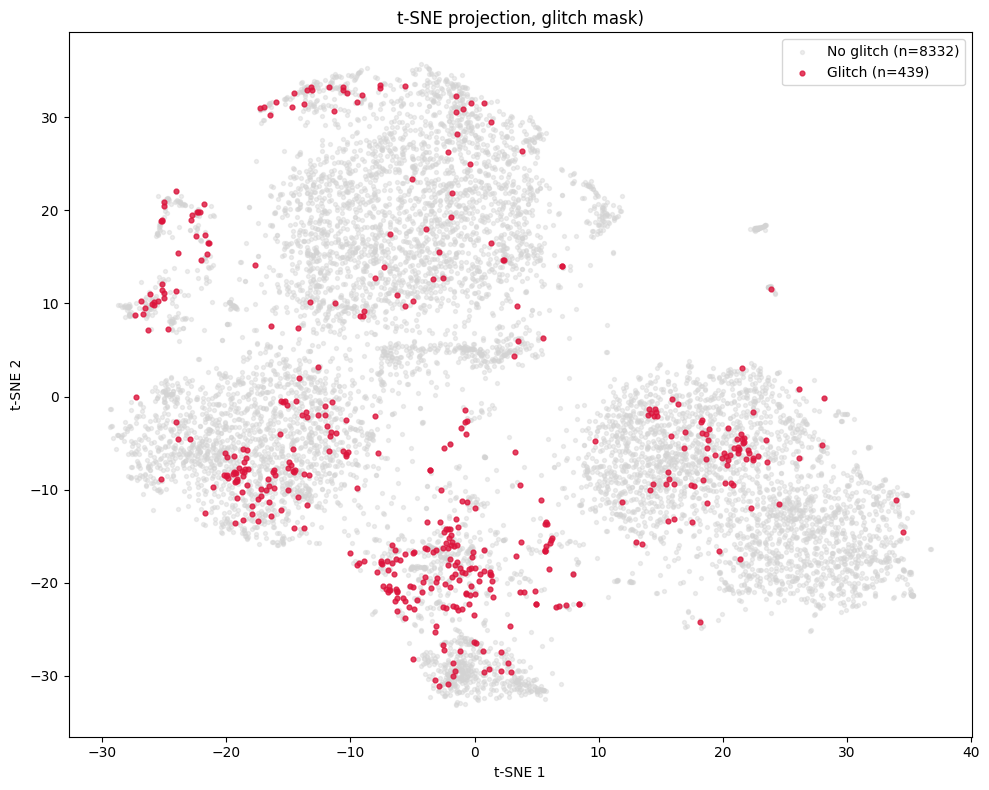

In [7]:
glitch_files = set(df_matched["file"].unique())
mask = df["file"].isin(glitch_files).to_numpy()

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_tsne[~mask, 0], X_tsne[~mask, 1],
           s=8, alpha=0.4, color="lightgray", zorder=1,
           label=f"No glitch (n={(~mask).sum()})")

ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
           s=12, alpha=0.8, color="crimson", zorder=2,
           label=f"Glitch (n={mask.sum()})")

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"t-SNE projection, glitch mask)")
ax.legend()
plt.tight_layout()
plt.show()

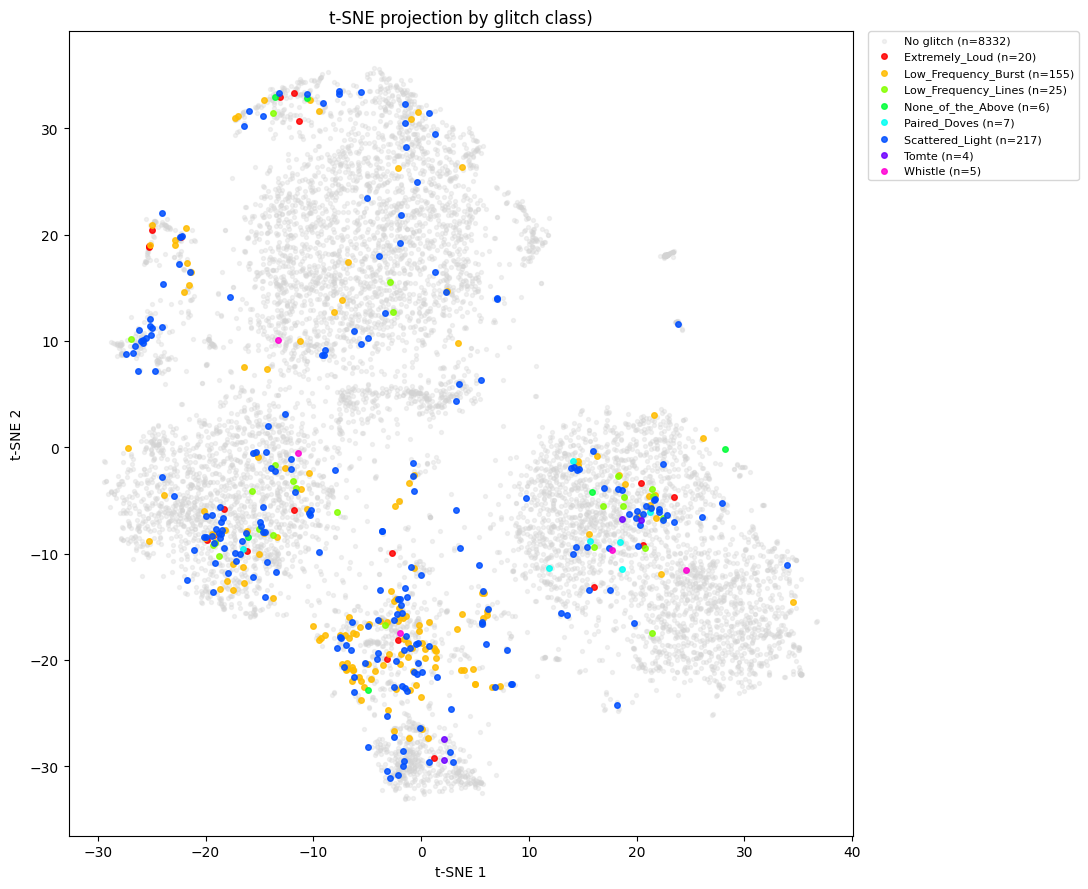

In [8]:
file_label = df_matched.groupby("file")["label"].agg(lambda s: s.value_counts().idxmax())

labels = df["file"].map(file_label).fillna("No glitch")
glitch_classes = sorted(c for c in labels.unique() if c != "No glitch")

cmap = plt.get_cmap("hsv", len(glitch_classes) + 1)
class_colors = {cls: cmap(i) for i, cls in enumerate(glitch_classes)}

fig, ax = plt.subplots(figsize=(11, 9))

no_glitch_mask = (labels == "No glitch").to_numpy()
ax.scatter(X_tsne[no_glitch_mask, 0], X_tsne[no_glitch_mask, 1],
           s=8, alpha=0.3, color="lightgray", zorder=1,
           label=f"No glitch (n={no_glitch_mask.sum()})")

for cls in glitch_classes:
    cls_mask = (labels == cls).to_numpy()
    ax.scatter(X_tsne[cls_mask, 0], X_tsne[cls_mask, 1],
               s=16, alpha=0.85, color=class_colors[cls], zorder=2,
               label=f"{cls} (n={cls_mask.sum()})")

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"t-SNE projection by glitch class)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

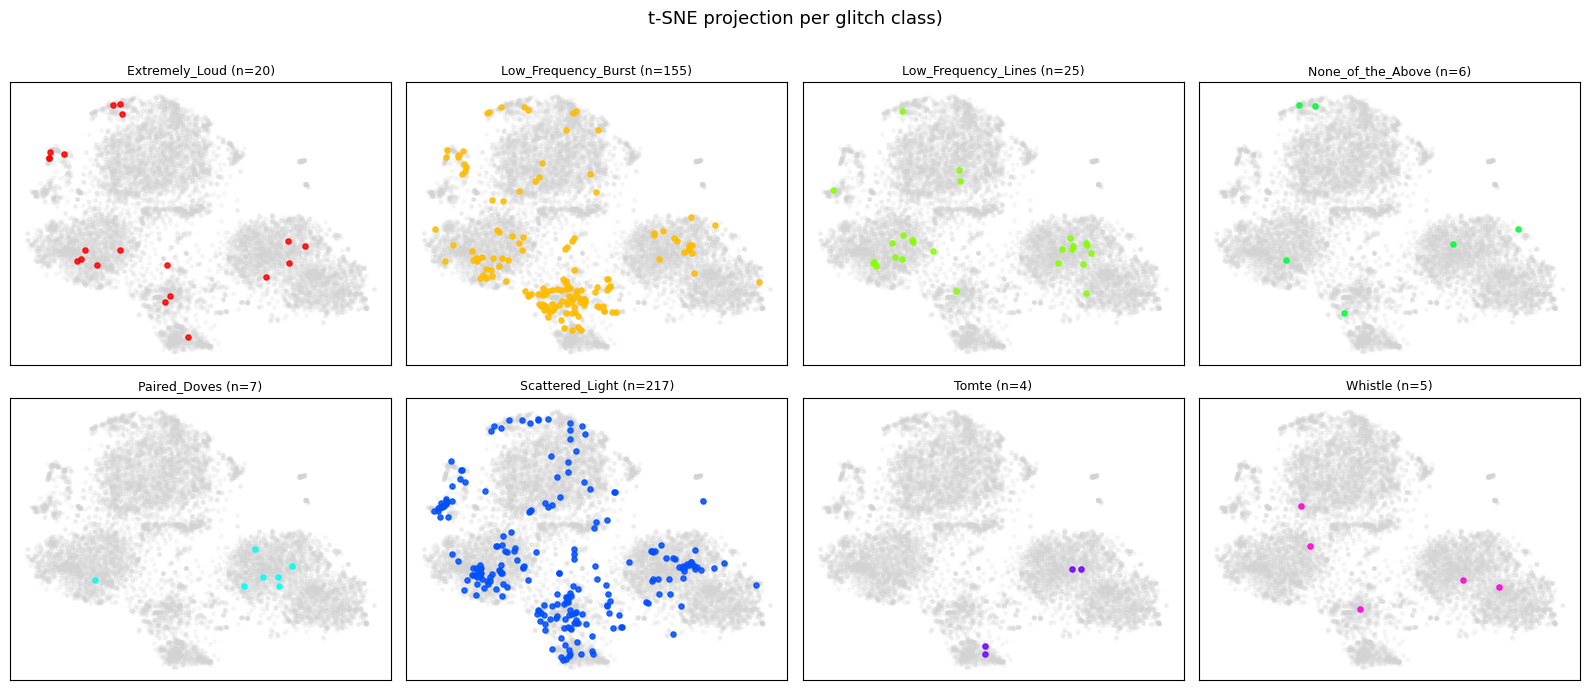

In [9]:
ncols = 4
nrows = int(np.ceil(len(glitch_classes) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows),
                          sharex=True, sharey=True)
axes = axes.flatten()

for ax, cls in zip(axes, glitch_classes):
    cls_mask = (labels == cls).to_numpy()

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
               s=6, alpha=0.15, color="lightgray", zorder=1)
    ax.scatter(X_tsne[cls_mask, 0], X_tsne[cls_mask, 1],
               s=14, alpha=0.85, color=class_colors[cls], zorder=2)

    ax.set_title(f"{cls} (n={cls_mask.sum()})", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide any unused grid cells if class count isn't a multiple of ncols
for ax in axes[len(glitch_classes):]:
    ax.axis("off")

fig.suptitle(f"t-SNE projection per glitch class)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import pymupdf
import plotly.graph_objects as go
import ipywidgets as widgets

from IPython.display import display, Image, clear_output

PATH = Path("year_Virgo_results_cut")
HISTOGRAMS_PATH = Path("event_histograms_output")
PDF_DPI = 150
IMAGE_WIDTH = 900

df["label"] = labels
df["run"] = "O3b"

def parse_date_from_filename(filename):
    filename = str(filename)

    match = re.search(r"(20\d{2})-(\d{2})-(\d{2})", filename)

    if match is None:
        raise ValueError(f"Could not extract date from filename: {filename}")
    year, month, day = match.groups()
    return pd.Timestamp(year=int(year), month=int(month),day=int(day))

df["_file_date"] = df["file"].apply(parse_date_from_filename)
df["_day_str"] = df["_file_date"].dt.strftime("%Y%m%d")
df["_qtransform_index"] = (df.groupby(["run", "station", "channel", "month_year", "_day_str"], sort=False).cumcount())

glitch_mask = (df["label"] != "No glitch").to_numpy()
df_plot = df.loc[glitch_mask].reset_index(drop=True)
X_tsne_plot = X_tsne[glitch_mask]

df_plot["trigger_time_parsed"] = pd.to_datetime(df_plot["trigger_time"],utc=True)

def make_histogram_filename(ts):
    ts = pd.Timestamp(ts)
    return (f"histogram_{ts.strftime('%Y%m%dT%H%M%S')}_{ts.microsecond // 1000:03d}.pdf")

gspy_times_by_file = (df_matched.groupby("file")["trigger (df_s)"].apply(list).to_dict())
def histogram_files_for(file):
    return [make_histogram_filename(t)for t in gspy_times_by_file.get(file, [])]

df_plot["histogram_files"] = (df_plot["file"].map(histogram_files_for))

print(f"Total glitch events plotted: {len(df_plot)}")
print("Events with at least one matched histogram:", (df_plot["histogram_files"].str.len() > 0).sum())
print("Events without a matched histogram:", (df_plot["histogram_files"].str.len() == 0).sum())

customdata = np.column_stack([np.arange(len(df_plot)),df_plot["file"].astype(str).to_numpy(),df_plot["label"].astype(str).to_numpy(),])

# =========================================================
# Create interactive t-SNE figure
# =========================================================

fig = go.FigureWidget(
    data=[
        go.Scatter(
            x=X_tsne_plot[:, 0],
            y=X_tsne_plot[:, 1],
            mode="markers",
            marker=dict(size=5,opacity=0.5),
            customdata=customdata,

            hovertemplate=(
                "<b>DataFrame index:</b> %{customdata[0]}<br>"
                "<b>File:</b> %{customdata[1]}<br>"
                "<b>Label:</b> %{customdata[2]}<br>"
                "<b>t-SNE 1:</b> %{x:.3f}<br>"
                "<b>t-SNE 2:</b> %{y:.3f}"
                "<extra></extra>"
            ),
        )
    ]
)


fig.update_layout(
    title=(f"Glitch events only — histograms | PCA Components = {PCA_COMPONENTS}"),
    xaxis_title="t-SNE 1",
    yaxis_title="t-SNE 2",
    width=1000,
    height=800,
    hovermode="closest"
)

image_output = widgets.Output(layout=widgets.Layout(width="1000px"))

# Cache rendered PDFs so repeated clicks are fast
pdf_cache = {}


# =========================================================
# PDF rendering
# =========================================================

def render_pdf(pdf_path, dpi=PDF_DPI):
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        raise FileNotFoundError(f"PDF not found:\n{pdf_path}")

    cache_key = str(pdf_path.resolve())

    if cache_key in pdf_cache:
        return pdf_cache[cache_key]

    pdf = pymupdf.open(str(pdf_path))

    try:
        if len(pdf) == 0:
            raise ValueError("PDF contains no pages.")

        page = pdf[0]
        zoom = dpi / 72.0
        matrix = pymupdf.Matrix(zoom,zoom)
        pix = page.get_pixmap(matrix=matrix,alpha=False)
        png_bytes = pix.tobytes("png")
        pdf_cache[cache_key] = png_bytes
        return png_bytes

    finally:
        pdf.close()


# =========================================================
# Display histograms associated with one event
# =========================================================

def display_histogram(df_index,file,label):
    histogram_files = df_plot.iloc[df_index]["histogram_files"]

    with image_output:
        clear_output(wait=True)
        print(f"DataFrame index : {df_index}")
        print(f"File            : {file}")
        print(f"Label           : {label}")
        print(f"t-SNE           : ({X_tsne_plot[df_index, 0]:.4f}, {X_tsne_plot[df_index, 1]:.4f})")
        print(f"Histograms      : {len(histogram_files)} matched trigger(s)")

        print()

        if not histogram_files:
            print("No Gravity Spy trigger recorded for this event.")
            return

        for i, histogram_file in enumerate(histogram_files,start=1):
            pdf_path = (HISTOGRAMS_PATH /histogram_file)
            print(f"[{i}/{len(histogram_files)}] {pdf_path}")

            try:
                png_bytes = render_pdf(pdf_path,dpi=PDF_DPI)
                display(Image(data=png_bytes,width=IMAGE_WIDTH))

            except FileNotFoundError as e:
                print("ERROR: PDF file was not found.")
                print(e)

            except Exception as e:
                print("ERROR while rendering PDF:")
                print(e)


def on_click(trace, points, selector):

    if not points.point_inds:
        return
    point_position = points.point_inds[0]

    df_index = int(trace.customdata[point_position][0])
    file = str(trace.customdata[point_position][1])
    label = str(trace.customdata[point_position][2])
    display_histogram(df_index=df_index,file=file,label=label)

fig.data[0].on_click(on_click)

display(fig) 
display(image_output)


Total glitch events plotted: 439
Events with at least one matched histogram: 439
Events without a matched histogram: 0


FigureWidget({
    'data': [{'customdata': array([[0, 'VRG01_HH3_2019-11-02.mseed', 'Scattered_Light'],
                                   [1, 'VRG01_HH3_2019-11-05.mseed', 'Scattered_Light'],
                                   [2, 'VRG01_HH3_2019-11-05.mseed', 'Scattered_Light'],
                                   ...,
                                   [436, 'VRG01_HH3_2020-03-27.mseed', 'Scattered_Light'],
                                   [437, 'VRG01_HH3_2020-03-27.mseed', 'Scattered_Light'],
                                   [438, 'VRG01_HH3_2020-03-27.mseed', 'Scattered_Light']],
                                  shape=(439, 3), dtype=object),
              'hovertemplate': ('<b>DataFrame index:</b> %{cust' ... '2:</b> %{y:.3f}<extra></extra>'),
              'marker': {'opacity': 0.5, 'size': 5},
              'mode': 'markers',
              'type': 'scatter',
              'uid': '5775f556-2506-4fa5-8851-522eb2dec197',
              'x': array([ 26.093287 ,  -7.6061883,  13

Output(layout=Layout(width='1000px'))